In [12]:
"""
step1_build_2000_2015.py
========================
產出: TSMC_Matrix_2000-2015.csv

NLP 說明:
  · PTT 股版: 爬蟲往回到 2000 年 (PTT 1997 年建站，有歷史資料)
  · 鉅亨新聞: API 約 2010 年起有資料；2000~2009 年 News 欄為 NaN → 正規化時填 0.5
  · 滾動市場確認錨向量: 同 2016-2026 版，從 2000 年開始累積

欄位輸出 (對齊規格):
  Date, Close, Volume, VIX_Close, ADR_Ret, SOX_Ret, FX_Ret,
  RSI_14, MACD, MACD_Signal, Ret_5D, Ret_10D, Ret_20D, Ret_42D,
  Vol_42D, Position_42D,
  PTT_Raw_Score, PTT_Volume, News_Raw_Score, News_Volume,
  Next_Day_Return, Target_Binary
"""

import os, time, json, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import yfinance as yf
from bs4 import BeautifulSoup
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── 設定 ─────────────────────────────────────────────────────────────────────
START_DATE   = "2000-01-01"
END_DATE     = "2015-12-31"
OUTPUT_FILE  = "TSMC_Matrix_2000-2015.csv"
NEWS_CACHE   = "cache_news_2000_2015.csv"
PTT_CACHE    = "cache_ptt_2000_2015.csv"
NLP_CACHE    = "cache_nlp_2000_2015.csv"

MIN_ANCHOR_DOCS = 30
MAX_ANCHOR_VECS = 3000

STATIC_BULL = [
    "台積電股價大漲，法人大買超",
    "台積電業績超預期，訂單爆增",
    "半導體景氣回升，外資看好台積電",
    "台積電產能滿載，市場看多",
    "台積電先進製程領先，前景樂觀",
]
STATIC_BEAR = [
    "台積電股價重挫，法人大賣超",
    "台積電業績不如預期，訂單減少",
    "半導體景氣下滑，台積電受衝擊",
    "台積電客戶庫存調整，前景保守",
    "地緣政治風險升溫，台積電承壓",
]


# ── STEP 1: 市場資料 ──────────────────────────────────────────────────────────
def build_market_features() -> pd.DataFrame:
    print("📥 [STEP 1] 下載市場資料 2000-2015...")
    raw = yf.download(["2330.TW","^VIX","^SOX","TSM","TWD=X"],
                      start=START_DATE, end=END_DATE, auto_adjust=True)

    if not isinstance(raw.columns, pd.MultiIndex):
        raise ValueError("yfinance 格式錯誤，請更新: pip install yfinance --upgrade")

    close = raw["Close"]
    df = pd.DataFrame({
        "Close":     close["2330.TW"],
        "Volume":    raw["Volume"]["2330.TW"],
        "VIX_Close": close["^VIX"],
        "SOX_Close": close["^SOX"],
        "TSM_Close": close["TSM"],
        "FX_Close":  close["TWD=X"],
    })
    df.index = pd.to_datetime(df.index).normalize()
    df.index.name = "Date"
    df.dropna(subset=["Close", "Volume"], inplace=True)

    for col in ["VIX_Close", "SOX_Close", "TSM_Close"]:
        df[col] = df[col].ffill(limit=10).bfill(limit=10)

    # TWD=X 2003 年前不完整
    df["FX_Close"] = df["FX_Close"].ffill(limit=10).bfill(limit=10).fillna(32.0)

    # 技術指標
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).ewm(com=13, min_periods=14).mean()
    loss  = (-delta.clip(upper=0)).ewm(com=13, min_periods=14).mean()
    df["RSI_14"] = 100 - 100 / (1 + gain / loss.replace(0, 1e-10))

    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"]        = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()

    for n in [5, 10, 20, 42]:
        df[f"Ret_{n}D"] = df["Close"].pct_change(n)

    df["Vol_42D"] = df["Close"].pct_change().rolling(42).std()
    roll_lo = df["Close"].rolling(42).min()
    roll_hi = df["Close"].rolling(42).max()
    df["Position_42D"] = (df["Close"] - roll_lo) / (roll_hi - roll_lo + 1e-10)

    df["SOX_Ret"] = df["SOX_Close"].pct_change()
    df["ADR_Ret"] = df["TSM_Close"].pct_change()
    df["FX_Ret"]  = df["FX_Close"].pct_change()

    df["Next_Day_Return"] = df["Close"].pct_change().shift(-1)
    df["Target_Binary"]   = (df["Next_Day_Return"] > 0).astype(int)

    df.drop(columns=["SOX_Close","TSM_Close","FX_Close"], inplace=True)
    # 只要台積電本身資料完整即保留（外部資料缺值填 0，不刪行）
    df["SOX_Ret"] = df.get("SOX_Ret", pd.Series(0, index=df.index)).fillna(0)
    df["ADR_Ret"] = df.get("ADR_Ret", pd.Series(0, index=df.index)).fillna(0)
    df["FX_Ret"]  = df.get("FX_Ret",  pd.Series(0, index=df.index)).fillna(0)
    df.dropna(subset=["RSI_14", "Vol_42D"], inplace=True)

    print(f"   ✅ {len(df)} 天 ({df.index.min().date()} ~ {df.index.max().date()})")
    return df


# ── STEP 2A: 鉅亨新聞 (2010 年後才有資料) ────────────────────────────────────
def anue_unix_range(date):
    naive = datetime(date.year, date.month, date.day)
    start = int(naive.timestamp()) - 8 * 3600
    return start, start + 86399


def fetch_anue_day(date):
    headers = {"User-Agent": "Mozilla/5.0","Referer":"https://news.cnyes.com/"}
    ts_s, ts_e = anue_unix_range(date)
    titles = []
    for page in range(1, 4):
        try:
            r = requests.get(
                "https://api.cnyes.com/media/api/v1/newslist/category/tw_stock",
                params={"startAt":ts_s,"endAt":ts_e,"limit":30,"page":page},
                headers=headers, timeout=15)
            if r.status_code != 200: break
            items = (r.json().get("items") or {}).get("data") or r.json().get("data") or []
            if not items: break
            for item in items:
                t = item.get("title","")
                if any(kw in t for kw in {"台積電","2330"}):
                    titles.append(t)
        except Exception:
            break
        time.sleep(0.3)
    return titles


def build_news_cache(trade_dates):
    if os.path.exists(NEWS_CACHE):
        cached = pd.read_csv(NEWS_CACHE, parse_dates=["Date"])
        done   = set(pd.to_datetime(cached["Date"]).dt.normalize())
        print(f"   📂 新聞快取: {len(done)} 天已完成")
    else:
        cached = pd.DataFrame(columns=["Date","News_Titles","News_Volume"])
        done   = set()

    # 2010 年前 Anue API 無資料，只爬 2010+
    valid_dates = [d for d in trade_dates
                   if pd.Timestamp(d).year >= 2010
                   and pd.Timestamp(d).normalize() not in done]
    if not valid_dates:
        print("   ✅ 新聞快取已完整")
        return cached

    print(f"   🕷️  鉅亨 API ({len(valid_dates)} 天, 2010~2015)...")
    rows = []
    for date in tqdm(valid_dates, desc="Anue"):
        titles = fetch_anue_day(date)
        rows.append({"Date":date,
                     "News_Titles":json.dumps(titles, ensure_ascii=False),
                     "News_Volume":len(titles)})
        if len(rows) % 100 == 0:
            cached = pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)
            cached.to_csv(NEWS_CACHE, index=False)
            rows = []
    if rows:
        cached = pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)
        cached.to_csv(NEWS_CACHE, index=False)

    cached["Date"] = pd.to_datetime(cached["Date"]).dt.normalize()
    return cached


# ── STEP 2B: PTT 股版 (2000 年起) ─────────────────────────────────────────────
def get_ptt_latest_page():
    try:
        r = requests.get("https://www.ptt.cc/bbs/Stock/index.html",
                         headers={"User-Agent":"Mozilla/5.0"},
                         cookies={"over18":"1"}, timeout=15)
        soup = BeautifulSoup(r.text,"html.parser")
        for btn in soup.select("a.btn.wide"):
            href = btn.get("href","")
            if "index" in href and "Stock" in href:
                return int(href.split("index")[1].split(".")[0]) + 1
    except Exception:
        pass
    return 4500


def parse_ptt_page(page_num):
    try:
        r = requests.get(
            f"https://www.ptt.cc/bbs/Stock/index{page_num}.html",
            headers={"User-Agent":"Mozilla/5.0"},
            cookies={"over18":"1"}, timeout=15)
        if r.status_code == 404:
            return [], True
        results = []
        for div in BeautifulSoup(r.text,"html.parser").select(".r-ent"):
            t_tag = div.select_one(".title a")
            d_tag = div.select_one(".date")
            if not t_tag or not d_tag: continue
            title = t_tag.text.strip()
            if not any(kw in title for kw in {"台積電","2330"}): continue
            try:
                parts = d_tag.text.strip().split("/")
                results.append((int(parts[0]), int(parts[1]), title))
            except Exception:
                pass
        return results, False
    except Exception:
        return [], False


def build_ptt_cache(trade_dates):
    if os.path.exists(PTT_CACHE):
        df = pd.read_csv(PTT_CACHE, parse_dates=["Date"])
        print(f"   📂 PTT 快取: {len(df)} 筆")
        return df

    print("   🕷️  PTT 爬蟲 (往回到 2000 年，需時較長)...")
    target_start = pd.Timestamp(START_DATE)
    max_page     = get_ptt_latest_page()
    all_posts    = []
    current_year = datetime.now().year
    prev_month   = datetime.now().month

    for page_num in tqdm(range(max_page, max(1, max_page-15000), -1),
                         desc="PTT", miniters=50):
        entries, is_404 = parse_ptt_page(page_num)
        if is_404: break
        page_oldest = None
        for m, d, title in entries:
            if m > prev_month + 3:
                current_year -= 1
            prev_month = m
            try:
                ts = pd.Timestamp(current_year, m, d)
            except Exception:
                continue
            if page_oldest is None or ts < page_oldest:
                page_oldest = ts
            if ts >= target_start:
                all_posts.append({"Date": ts, "Title": title})
        if page_oldest is not None and page_oldest < target_start:
            break
        time.sleep(0.2)

    df_ptt = (pd.DataFrame(all_posts) if all_posts
              else pd.DataFrame(columns=["Date","Title"]))
    df_ptt["Date"] = pd.to_datetime(df_ptt["Date"]).dt.normalize()
    df_ptt.to_csv(PTT_CACHE, index=False)
    print(f"   ✅ PTT: {len(df_ptt)} 筆")
    return df_ptt


# ── STEP 3: 滾動市場確認錨向量 NLP ───────────────────────────────────────────
def build_nlp_features(trade_dates, news_cache, ptt_cache, df_market):
    print("\n🧠 [STEP 3] 滾動錨向量 NLP 計算 (2000-2015)...")
    model = SentenceTransformer("shibing624/text2vec-base-chinese")

    static_bull = model.encode(STATIC_BULL, show_progress_bar=False).mean(axis=0)
    static_bear = model.encode(STATIC_BEAR, show_progress_bar=False).mean(axis=0)

    news_by_date = {}
    if not news_cache.empty:
        news_cache["Date"] = pd.to_datetime(news_cache["Date"]).dt.normalize()
        for _, row in news_cache.iterrows():
            titles = json.loads(row["News_Titles"]) if isinstance(row["News_Titles"],str) else []
            news_by_date[row["Date"]] = titles

    ptt_by_date = {}
    if not ptt_cache.empty:
        ptt_cache["Date"] = pd.to_datetime(ptt_cache["Date"]).dt.normalize()
        for d, grp in ptt_cache.groupby("Date"):
            ptt_by_date[d] = grp["Title"].tolist()

    # 斷點續跑
    if os.path.exists(NLP_CACHE):
        nlp_done  = pd.read_csv(NLP_CACHE, parse_dates=["Date"])
        done_dates = set(pd.to_datetime(nlp_done["Date"]).dt.normalize())
        print(f"   📂 NLP 快取: {len(done_dates)} 天已完成")
    else:
        nlp_done   = pd.DataFrame()
        done_dates = set()

    # 重建錨向量池
    news_bull_pool, news_bear_pool = [], []
    ptt_bull_pool,  ptt_bear_pool  = [], []

    for date in sorted(done_dates):
        d = pd.Timestamp(date).normalize()
        if d not in df_market.index: continue
        target = int(df_market.loc[d, "Target_Binary"])
        for by_date, b_pool, e_pool in [
            (news_by_date, news_bull_pool, news_bear_pool),
            (ptt_by_date,  ptt_bull_pool,  ptt_bear_pool),
        ]:
            titles = by_date.get(d, [])
            if titles:
                vecs = model.encode(titles, show_progress_bar=False)
                (b_pool if target == 1 else e_pool).extend(vecs)

    for pool in [news_bull_pool, news_bear_pool, ptt_bull_pool, ptt_bear_pool]:
        if len(pool) > MAX_ANCHOR_VECS: del pool[:-MAX_ANCHOR_VECS]

    remaining = [d for d in trade_dates
                 if pd.Timestamp(d).normalize() not in done_dates]
    print(f"   📅 剩餘 {len(remaining)} 天...")

    def get_anchor(pool, static):
        return np.mean(pool, axis=0) if len(pool) >= MIN_ANCHOR_DOCS else static

    new_rows = []
    for date in tqdm(remaining, desc="NLP"):
        d = pd.Timestamp(date).normalize()

        news_titles = news_by_date.get(d, [])
        ptt_titles  = ptt_by_date.get(d, [])

        news_bull = get_anchor(news_bull_pool, static_bull)
        news_bear = get_anchor(news_bear_pool, static_bear)
        ptt_bull  = get_anchor(ptt_bull_pool,  static_bull)
        ptt_bear  = get_anchor(ptt_bear_pool,  static_bear)

        def score(titles, b_anc, e_anc):
            if not titles: return None
            v = model.encode(titles, show_progress_bar=False)
            return float((cosine_similarity(v, b_anc.reshape(1,-1)) -
                          cosine_similarity(v, e_anc.reshape(1,-1))).mean())

        new_rows.append({
            "Date":           d,
            "News_Raw_Score": score(news_titles, news_bull, news_bear),
            "News_Volume":    len(news_titles),
            "PTT_Raw_Score":  score(ptt_titles,  ptt_bull,  ptt_bear),
            "PTT_Volume":     len(ptt_titles),
        })

        if d in df_market.index:
            target = int(df_market.loc[d,"Target_Binary"])
            if news_titles:
                vecs = model.encode(news_titles, show_progress_bar=False)
                p = news_bull_pool if target==1 else news_bear_pool
                p.extend(vecs)
                if len(p) > MAX_ANCHOR_VECS: del p[:-MAX_ANCHOR_VECS]
            if ptt_titles:
                vecs = model.encode(ptt_titles, show_progress_bar=False)
                p = ptt_bull_pool if target==1 else ptt_bear_pool
                p.extend(vecs)
                if len(p) > MAX_ANCHOR_VECS: del p[:-MAX_ANCHOR_VECS]

        if len(new_rows) % 50 == 0:
            nlp_done = pd.concat([nlp_done, pd.DataFrame(new_rows)], ignore_index=True)
            nlp_done.to_csv(NLP_CACHE, index=False)
            new_rows = []

    if new_rows:
        nlp_done = pd.concat([nlp_done, pd.DataFrame(new_rows)], ignore_index=True)
        nlp_done.to_csv(NLP_CACHE, index=False)

    nlp_done["Date"] = pd.to_datetime(nlp_done["Date"]).dt.normalize()
    nlp_done = nlp_done.drop_duplicates("Date").set_index("Date").sort_index()
    return nlp_done


# ── STEP 4: 組裝 ─────────────────────────────────────────────────────────────
def assemble_and_save(df_market, df_nlp):
    print("\n🧩 [STEP 4] 組裝矩陣...")
    df = df_market.copy()
    df.index = pd.to_datetime(df.index).normalize()
    df = df.join(df_nlp, how="left")

    col_order = [
        "Close","Volume","VIX_Close","ADR_Ret","SOX_Ret","FX_Ret",
        "RSI_14","MACD","MACD_Signal",
        "Ret_5D","Ret_10D","Ret_20D","Ret_42D",
        "Vol_42D","Position_42D",
        "PTT_Raw_Score","PTT_Volume",
        "News_Raw_Score","News_Volume",
        "Next_Day_Return","Target_Binary",
    ]
    df = df[[c for c in col_order if c in df.columns]]
    df.index.name = "Date"
    df = df.reset_index()
    df.to_csv(OUTPUT_FILE, index=False)

    up = int(df["Target_Binary"].sum())
    print(f"\n{'='*60}")
    print(f"🎉 {OUTPUT_FILE}")
    print(f"   {len(df)} 天  |  漲:{up} / 跌:{len(df)-up}  |  基準:{max(up,len(df)-up)/len(df):.1%}")
    print(f"   NLP 有效: News={df['News_Raw_Score'].notna().sum()} / PTT={df['PTT_Raw_Score'].notna().sum()}")
    print(f"{'='*60}\n")


if __name__ == "__main__":
    print("="*60)
    print("🚀 TSMC 超大矩陣 Step 1 — 2000~2015 (含 NLP)")
    print("="*60)
    df_market   = build_market_features()
    news_cache  = build_news_cache(df_market.index)
    ptt_cache   = build_ptt_cache(df_market.index)
    df_nlp      = build_nlp_features(df_market.index, news_cache, ptt_cache, df_market)
    assemble_and_save(df_market, df_nlp)
    print("✅ 完成 → 接著執行 step2_build_2016_2026.py")

🚀 TSMC 超大矩陣 Step 1 — 2000~2015 (含 NLP)
📥 [STEP 1] 下載市場資料 2000-2015...


[*********************100%***********************]  5 of 5 completed


   ✅ 3996 天 (2000-03-02 ~ 2015-12-30)
   📂 新聞快取: 1482 天已完成
   ✅ 新聞快取已完整
   📂 PTT 快取: 0 筆

🧠 [STEP 3] 滾動錨向量 NLP 計算 (2000-2015)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: shibing624/text2vec-base-chinese
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   📂 NLP 快取: 3996 天已完成
   📅 剩餘 0 天...


NLP: 0it [00:00, ?it/s]


🧩 [STEP 4] 組裝矩陣...



🎉 TSMC_Matrix_2000-2015.csv
   3996 天  |  漲:1785 / 跌:2211  |  基準:55.3%
   NLP 有效: News=392 / PTT=0

✅ 完成 → 接著執行 step2_build_2016_2026.py


In [ ]:
"""
step2_build_2016_2026.py
=========================
產出: TSMC_Matrix_2016-2026.csv

NLP 情緒分數採用「滾動市場確認錨向量」(Rolling Market-Confirmed Anchors):
  ─────────────────────────────────────────────────────────────────
  傳統靜態作法:  固定幾句「台積電大漲/大跌」例句 → 整個 10 年用同樣的錨向量
  本版作法:      每一天的分數都用「到昨天為止，市場已確認漲跌日的文章」建立錨向量
  ─────────────────────────────────────────────────────────────────

  Day t 的計算流程（嚴格 OOS，無未來函數）:
    Step 1: 收集 Day 1 ~ Day t-1 中：
              · 實際上漲日(Target=1) 的新聞/PTT 標題 → 編碼 → 看多錨向量 bull_anchor_t
              · 實際下跌日(Target=0) 的新聞/PTT 標題 → 編碼 → 看空錨向量 bear_anchor_t
    Step 2: 對 Day t 的每篇文章計算 cosine(article, bull_anchor_t) - cosine(article, bear_anchor_t)
    Step 3: 平均 → Day t 的原始情緒分數 (PTT_Raw_Score / News_Raw_Score)
    Step 4: Day t 收盤後，把 Day t 的文章（標記 Target_Binary[t]）加入錨向量池
    Step 5: 重複 Step 1~4 直到最後一天

  隨時間演化效果:
    2016 初期: 錨向量 ≈ 靜態備用（語料庫為空）
    2017 起:   錨向量開始包含「台股漲跌時的真實詞彙」
    2022 後:   錨向量已整合 AI、升息、地緣政治等新興情緒語言

  欄位輸出: PTT_Raw_Score / News_Raw_Score (原始 cosine 差值，未正規化)
    → 正規化在 02_stress_test.py 的每個訓練窗口內獨立執行，確保零未來函數

執行前提:
  pip install yfinance requests beautifulsoup4 sentence-transformers
              scikit-learn tqdm pandas numpy

估計時間: 3~5 小時（NLP 計算為主要耗時）
斷點續跑: 快取檔案 cache_ptt_2016_2026.csv / cache_news_2016_2026.csv
"""

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import yfinance as yf
from bs4 import BeautifulSoup
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ===========================================================================
# ⚙️  設定
# ===========================================================================
START_DATE  = "2016-01-01"
END_DATE    = "2026-04-16"
OUTPUT_FILE = "TSMC_Matrix_2016-2026.csv"   # step3 會合併成 TSMC_matrix_2000-2026.csv
NEWS_CACHE  = "cache_news_2016_2026.csv"
PTT_CACHE   = "cache_ptt_2016_2026.csv"
NLP_CACHE   = "cache_nlp_scores.csv"    # NLP 分數中間結果（斷點續跑用）

# 初始靜態備用錨向量（語料庫累積到 MIN_ANCHOR_DOCS 篇前使用）
MIN_ANCHOR_DOCS = 30   # 至少累積 30 篇才切換到動態錨向量

STATIC_BULL = [
    "台積電股價大漲，法人大買超",
    "台積電業績超預期，訂單爆增",
    "半導體景氣回升，外資看好台積電",
    "台積電產能滿載，AI 需求強勁",
    "台積電先進製程領先，市場看多",
]
STATIC_BEAR = [
    "台積電股價重挫，法人大賣超",
    "台積電業績不如預期，訂單減少",
    "半導體景氣下滑，台積電受衝擊",
    "台積電客戶庫存調整，前景保守",
    "地緣政治風險升溫，台積電承壓",
]

# 錨向量池上限（避免記憶體無限增長）
MAX_ANCHOR_VECS = 3000

# ===========================================================================
# 📥  STEP 1: 市場資料 + 技術指標 + 標籤
# ===========================================================================
def build_market_features() -> pd.DataFrame:
    print("📥 [STEP 1] 下載市場資料 (Yahoo Finance)...")

    # ── 各 ticker 分開下載，避免 MultiIndex 對齊問題 ────────────────────────
    def safe_download(ticker, start, end):
        try:
            df = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False)
            df.index = pd.to_datetime(df.index).normalize()
            return df
        except Exception as e:
            print(f"   ⚠️  {ticker} 下載失敗: {e}")
            return pd.DataFrame()

    tw   = safe_download("2330.TW", START_DATE, END_DATE)
    vix  = safe_download("^VIX",    START_DATE, END_DATE)
    sox  = safe_download("^SOX",    START_DATE, END_DATE)
    tsm  = safe_download("TSM",     START_DATE, END_DATE)
    fx   = safe_download("TWD=X",   START_DATE, END_DATE)

    if tw.empty:
        raise ValueError("2330.TW 資料下載失敗，請確認網路連線")

    # ── 以台積電交易日為主軸，join 其他資料 ─────────────────────────────────
    df = pd.DataFrame(index=tw.index)
    df.index.name = "Date"

    df["Close"]  = tw["Close"]
    df["Volume"] = tw["Volume"]

    # 各外部資料 reindex 到台股交易日，再 ffill（最多填 10 天，覆蓋美股長假）
    for col_name, src, price_col in [
        ("VIX_Close", vix, "Close"),
        ("SOX_Close", sox, "Close"),
        ("TSM_Close", tsm, "Close"),
        ("FX_Close",  fx,  "Close"),
    ]:
        if not src.empty and price_col in src.columns:
            series = src[price_col].reindex(df.index)
            series = series.ffill(limit=10).bfill(limit=10)
            df[col_name] = series
        else:
            df[col_name] = np.nan
            print(f"   ⚠️  {col_name} 無資料，填 NaN")

    # ── 台積電本身不能有 NaN（唯一硬性刪行條件）────────────────────────────
    df.dropna(subset=["Close", "Volume"], inplace=True)

    # ── 技術指標（只依賴 2330.TW Close，不受外部資料影響）──────────────────
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).ewm(com=13, min_periods=14).mean()
    loss  = (-delta.clip(upper=0)).ewm(com=13, min_periods=14).mean()
    df["RSI_14"] = 100 - 100 / (1 + gain / loss.replace(0, 1e-10))

    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"]        = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()

    for n in [5, 10, 20, 42]:
        df[f"Ret_{n}D"] = df["Close"].pct_change(n)

    df["Vol_42D"] = df["Close"].pct_change().rolling(42).std()

    roll_lo = df["Close"].rolling(42).min()
    roll_hi = df["Close"].rolling(42).max()
    df["Position_42D"] = (df["Close"] - roll_lo) / (roll_hi - roll_lo + 1e-10)

    # ── 總經報酬率（外部資料有缺值時填 0，代表「無訊號」而非刪行）──────────
    df["SOX_Ret"] = df["SOX_Close"].pct_change().fillna(0)
    df["ADR_Ret"] = df["TSM_Close"].pct_change().fillna(0)
    df["FX_Ret"]  = df["FX_Close"].pct_change().fillna(0)

    # ── 預測標籤 ─────────────────────────────────────────────────────────────
    df["Next_Day_Return"] = df["Close"].pct_change().shift(-1)
    df["Target_Binary"]   = (df["Next_Day_Return"] > 0).astype(int)

    df.drop(columns=["SOX_Close", "TSM_Close", "FX_Close"], inplace=True)

    # 只刪技術指標暖機期（前 42 天 Vol_42D 為 NaN 是正常的）
    df.dropna(subset=["RSI_14", "Vol_42D"], inplace=True)

    # 診斷：印出各欄 NaN 比率
    nan_pct = df.isnull().mean().sort_values(ascending=False)
    nan_pct = nan_pct[nan_pct > 0]
    if not nan_pct.empty:
        print(f"   ⚠️  剩餘 NaN 欄位 (已保留，不影響模型):")
        for col, pct in nan_pct.items():
            print(f"      {col}: {pct:.1%}")

    print(f"   ✅ {len(df)} 個交易日 ({df.index.min().date()} ~ {df.index.max().date()})")
    return df


# ===========================================================================
# 🕷️  STEP 2A: 鉅亨網 (Anue) 新聞 API
# ===========================================================================
def anue_unix_range(date: pd.Timestamp):
    """台灣時間 UTC+8，當日 00:00:00 ~ 23:59:59 的 Unix 秒"""
    naive  = datetime(date.year, date.month, date.day)
    start  = int(naive.timestamp()) - 8 * 3600
    return start, start + 86399


def fetch_anue_day(date: pd.Timestamp):
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36",
        "Referer":    "https://news.cnyes.com/",
    }
    ts_s, ts_e = anue_unix_range(date)
    keywords   = {"台積電", "2330"}
    titles     = []

    for page in range(1, 6):
        try:
            r = requests.get(
                "https://api.cnyes.com/media/api/v1/newslist/category/tw_stock",
                params={"startAt": ts_s, "endAt": ts_e, "limit": 30, "page": page},
                headers=headers, timeout=15,
            )
            if r.status_code != 200:
                break
            data  = r.json()
            items = (data.get("items") or {}).get("data") \
                    or data.get("data") or []
            if not items:
                break
            for item in items:
                t = item.get("title", "")
                if any(kw in t for kw in keywords):
                    titles.append(t)
        except Exception:
            break
        time.sleep(0.3)

    return titles


def build_news_cache(trade_dates: pd.DatetimeIndex) -> pd.DataFrame:
    if os.path.exists(NEWS_CACHE):
        cached = pd.read_csv(NEWS_CACHE, parse_dates=["Date"])
        done   = set(pd.to_datetime(cached["Date"]).dt.normalize())
        print(f"   📂 新聞快取: {len(done)} 天已完成")
    else:
        cached = pd.DataFrame(columns=["Date", "News_Titles", "News_Volume"])
        done   = set()

    remaining = [d for d in trade_dates if pd.Timestamp(d).normalize() not in done]
    if not remaining:
        return cached

    print(f"   🕷️  鉅亨 API 爬取 ({len(remaining)} 天)...")
    rows = []
    for date in tqdm(remaining, desc="Anue"):
        titles = fetch_anue_day(date)
        rows.append({
            "Date":        date,
            "News_Titles": json.dumps(titles, ensure_ascii=False),
            "News_Volume": len(titles),
        })
        if len(rows) % 100 == 0:
            cached = pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)
            cached.to_csv(NEWS_CACHE, index=False)
            rows = []

    if rows:
        cached = pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)
        cached.to_csv(NEWS_CACHE, index=False)

    cached["Date"] = pd.to_datetime(cached["Date"]).dt.normalize()
    return cached


# ===========================================================================
# 🕷️  STEP 2B: PTT 股版爬蟲 (修正跨年邏輯)
# ===========================================================================
def _make_ptt_session() -> requests.Session:
    """
    建立帶有正確 cookie 的 PTT Session。
    PTT 需要先送出 over18 同意表單才能存取股版。
    """
    session = requests.Session()
    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
        "Accept":          "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "zh-TW,zh;q=0.9,en;q=0.8",
        "Referer":         "https://www.ptt.cc/bbs/Stock/index.html",
    })
    # 方法 1: 直接設定 cookie（多數情況有效）
    session.cookies.set("over18", "1", domain="www.ptt.cc")

    # 方法 2: 模擬送出同意表單（若方法 1 失效時的 fallback）
    try:
        r = session.post(
            "https://www.ptt.cc/ask/over18",
            data={"from": "/bbs/Stock/index.html", "yes": "yes"},
            timeout=15,
        )
        if r.status_code == 200:
            pass   # cookie 已自動更新
    except Exception:
        pass

    return session


def get_ptt_latest_page(session: requests.Session) -> int:
    try:
        r    = session.get("https://www.ptt.cc/bbs/Stock/index.html", timeout=15)
        soup = BeautifulSoup(r.text, "html.parser")
        for btn in soup.select("a.btn.wide"):
            href = btn.get("href", "")
            if "index" in href and "Stock" in href:
                num = href.split("index")[1].split(".")[0]
                return int(num) + 1
    except Exception:
        pass
    return 4500


def parse_ptt_page(page_num: int, session: requests.Session,
                   retry: int = 3) -> tuple:
    """
    回傳 ([(month, day, title)], is_end_of_board)
    is_end_of_board=True 代表 404 或已到版首
    """
    url = f"https://www.ptt.cc/bbs/Stock/index{page_num}.html"
    for attempt in range(retry):
        try:
            r = session.get(url, timeout=15)
            if r.status_code == 404:
                return [], True
            if r.status_code == 200:
                break
            time.sleep(1.5)
        except Exception:
            time.sleep(2)
    else:
        return [], False   # 連線失敗但不是 404，繼續嘗試下一頁

    # 若被重導向到 over18 頁面，重新送出同意
    if "over18" in r.url or "ask" in r.url:
        try:
            session.post("https://www.ptt.cc/ask/over18",
                         data={"from": f"/bbs/Stock/index{page_num}.html", "yes": "yes"},
                         timeout=10)
            r = session.get(url, timeout=15)
        except Exception:
            return [], False

    soup    = BeautifulSoup(r.text, "html.parser")
    results = []
    for div in soup.select(".r-ent"):
        t_tag = div.select_one(".title a")
        d_tag = div.select_one(".date")
        if not t_tag or not d_tag:
            continue
        title = t_tag.text.strip()
        if not any(kw in title for kw in {"台積電", "2330"}):
            continue
        try:
            parts = d_tag.text.strip().split("/")
            results.append((int(parts[0]), int(parts[1]), title))
        except Exception:
            pass

    return results, False


def build_ptt_cache(trade_dates: pd.DatetimeIndex) -> pd.DataFrame:
    if os.path.exists(PTT_CACHE):
        df = pd.read_csv(PTT_CACHE, parse_dates=["Date"])
        print(f"   📂 PTT 快取: {len(df)} 筆文章")
        return df

    print("   🕷️  PTT 股版爬蟲 (Session 模式，從最新頁往舊頁)...")
    session      = _make_ptt_session()
    target_start = pd.Timestamp(START_DATE)
    max_page     = get_ptt_latest_page(session)
    all_posts    = []
    current_year = datetime.now().year
    prev_month   = datetime.now().month
    consecutive_empty = 0   # 連續空頁計數（防無限空跑）

    print(f"   📄 最新頁碼: {max_page}，開始往回爬...")

    for page_num in tqdm(range(max_page, max(1, max_page - 12000), -1),
                         desc="PTT", miniters=100):
        entries, is_end = parse_ptt_page(page_num, session)

        if is_end:
            break

        if not entries:
            consecutive_empty += 1
            if consecutive_empty > 20:
                print(f"\n   ⚠️  連續 20 頁無台積電相關文章，停止爬蟲")
                break
            time.sleep(0.3)
            continue

        consecutive_empty = 0
        page_oldest = None

        for m, d, title in entries:
            # 跨年偵測：月份「往後跳」超過 3 個月 → 年份 -1
            if m > prev_month + 3:
                current_year -= 1
            prev_month = m

            try:
                ts = pd.Timestamp(current_year, m, d)
            except Exception:
                continue

            if page_oldest is None or ts < page_oldest:
                page_oldest = ts

            if ts >= target_start:
                all_posts.append({"Date": ts, "Title": title})

        # 整頁最早文章已比目標起始日更早 → 停止
        if page_oldest is not None and page_oldest < target_start:
            break

        time.sleep(0.2)

    df_ptt = (pd.DataFrame(all_posts) if all_posts
              else pd.DataFrame(columns=["Date", "Title"]))
    df_ptt["Date"] = pd.to_datetime(df_ptt["Date"]).dt.normalize()
    df_ptt.to_csv(PTT_CACHE, index=False)

    if df_ptt.empty:
        print("   ⚠️  PTT 爬蟲未抓到任何資料")
        print("      可能原因: PTT 反爬機制 / 網路封鎖")
        print("      影響: PTT_Raw_Score 將全部填 NaN，正規化後以 0.5 代入")
    else:
        print(f"   ✅ PTT 完成: {len(df_ptt)} 筆文章")

    return df_ptt


# ===========================================================================
# 🧠  STEP 3: 滾動市場確認錨向量 NLP 計算
#
#  核心原理:
#    · 每天計算分數前，錨向量池裡只有「昨天以前」已確認漲跌的文章
#    · 計算完分數後，才把今天的文章（標記今天的漲跌結果）加入池子
#    · 因此每天的分數永遠只依賴過去的資訊 → 嚴格 OOS
# ===========================================================================
def compute_one_day_score(titles: list,
                           bull_anchor: np.ndarray,
                           bear_anchor: np.ndarray,
                           model) -> float | None:
    """計算一組標題對當前錨向量的原始情緒分數"""
    if not titles:
        return None
    vecs     = model.encode(titles, show_progress_bar=False)
    bull_sim = cosine_similarity(vecs, bull_anchor.reshape(1, -1)).flatten()
    bear_sim = cosine_similarity(vecs, bear_anchor.reshape(1, -1)).flatten()
    return float((bull_sim - bear_sim).mean())


def build_nlp_features(
    trade_dates:  pd.DatetimeIndex,
    news_cache:   pd.DataFrame,
    ptt_cache:    pd.DataFrame,
    df_market:    pd.DataFrame,
) -> pd.DataFrame:
    """
    逐日計算 NLP 情緒原始分數，使用滾動市場確認錨向量。
    支援斷點續跑（cache_nlp_scores.csv）。
    """
    print("\n🧠 [STEP 3] 載入 SentenceTransformer 模型...")
    model = SentenceTransformer("shibing624/text2vec-base-chinese")

    # ── 靜態備用錨向量 ───────────────────────────────────────────────────
    static_bull = model.encode(STATIC_BULL, show_progress_bar=False).mean(axis=0)
    static_bear = model.encode(STATIC_BEAR, show_progress_bar=False).mean(axis=0)

    # ── 建立日期 → 標題 字典 ─────────────────────────────────────────────
    news_by_date: dict[pd.Timestamp, list] = {}
    if not news_cache.empty:
        news_cache["Date"] = pd.to_datetime(news_cache["Date"]).dt.normalize()
        for _, row in news_cache.iterrows():
            titles = (json.loads(row["News_Titles"])
                      if isinstance(row["News_Titles"], str) else [])
            news_by_date[row["Date"]] = titles

    ptt_by_date: dict[pd.Timestamp, list] = {}
    if not ptt_cache.empty:
        ptt_cache["Date"] = pd.to_datetime(ptt_cache["Date"]).dt.normalize()
        for d, grp in ptt_cache.groupby("Date"):
            ptt_by_date[d] = grp["Title"].tolist()

    # ── 斷點續跑：載入已算完的分數 ──────────────────────────────────────
    if os.path.exists(NLP_CACHE):
        nlp_done = pd.read_csv(NLP_CACHE, parse_dates=["Date"])
        nlp_done["Date"] = pd.to_datetime(nlp_done["Date"]).dt.normalize()
        done_dates = set(nlp_done["Date"])
        print(f"   📂 NLP 快取: {len(done_dates)} 天已完成")
    else:
        nlp_done   = pd.DataFrame()
        done_dates = set()

    # ── 動態錨向量池 ─────────────────────────────────────────────────────
    # 向量池: list of np.ndarray (shape [768,])
    # 重建已完成天數的向量池，讓未完成的天數能用正確的錨向量
    news_bull_pool: list[np.ndarray] = []
    news_bear_pool: list[np.ndarray] = []
    ptt_bull_pool:  list[np.ndarray] = []
    ptt_bear_pool:  list[np.ndarray] = []

    print("   🔄  重建錨向量池（回放已完成的天數）...")
    for date in tqdm(sorted(done_dates), desc="  重建中", leave=False):
        d = pd.Timestamp(date).normalize()
        if d not in df_market.index:
            continue
        target = int(df_market.loc[d, "Target_Binary"])

        for by_date, bull_pool, bear_pool in [
            (news_by_date, news_bull_pool, news_bear_pool),
            (ptt_by_date,  ptt_bull_pool,  ptt_bear_pool),
        ]:
            titles = by_date.get(d, [])
            if titles:
                vecs = model.encode(titles, show_progress_bar=False)
                pool = bull_pool if target == 1 else bear_pool
                pool.extend(vecs)

    # 修剪
    for pool in [news_bull_pool, news_bear_pool,
                 ptt_bull_pool,  ptt_bear_pool]:
        if len(pool) > MAX_ANCHOR_VECS:
            del pool[:-MAX_ANCHOR_VECS]

    # ── 逐日計算 ─────────────────────────────────────────────────────────
    remaining = [d for d in trade_dates
                 if pd.Timestamp(d).normalize() not in done_dates]
    print(f"\n   📅 開始逐日 NLP 計算 (剩餘 {len(remaining)} 天)...")

    new_rows  = []
    save_every = 50   # 每 50 天存一次斷點

    for date in tqdm(remaining, desc="NLP 分數計算"):
        d = pd.Timestamp(date).normalize()

        # ── 用當前錨向量池計算今天的分數 ──────────────────────────────
        def get_anchor(pool, static):
            return np.mean(pool, axis=0) if len(pool) >= MIN_ANCHOR_DOCS else static

        news_bull = get_anchor(news_bull_pool, static_bull)
        news_bear = get_anchor(news_bear_pool, static_bear)
        ptt_bull  = get_anchor(ptt_bull_pool,  static_bull)
        ptt_bear  = get_anchor(ptt_bear_pool,  static_bear)

        news_titles = news_by_date.get(d, [])
        ptt_titles  = ptt_by_date.get(d, [])

        # 各自獨立編碼（news 和 ptt 使用各自的錨向量）
        news_vecs = model.encode(news_titles, show_progress_bar=False) if news_titles else None
        ptt_vecs  = model.encode(ptt_titles,  show_progress_bar=False) if ptt_titles  else None

        if news_vecs is not None:
            bs = cosine_similarity(news_vecs, news_bull.reshape(1,-1)).flatten()
            es = cosine_similarity(news_vecs, news_bear.reshape(1,-1)).flatten()
            news_raw = float((bs - es).mean())
        else:
            news_raw = None

        if ptt_vecs is not None:
            bs = cosine_similarity(ptt_vecs, ptt_bull.reshape(1,-1)).flatten()
            es = cosine_similarity(ptt_vecs, ptt_bear.reshape(1,-1)).flatten()
            ptt_raw = float((bs - es).mean())
        else:
            ptt_raw = None

        new_rows.append({
            "Date":           d,
            "PTT_Raw_Score":  ptt_raw,
            "PTT_Volume":     len(ptt_titles),
            "News_Raw_Score": news_raw,
            "News_Volume":    len(news_titles),
        })

        # ── 今天收盤後，把今天的文章加入錨向量池 ─────────────────────
        if d in df_market.index:
            target = int(df_market.loc[d, "Target_Binary"])

            if news_vecs is not None:
                pool = news_bull_pool if target == 1 else news_bear_pool
                pool.extend(news_vecs)
                if len(pool) > MAX_ANCHOR_VECS:
                    del pool[:-MAX_ANCHOR_VECS]

            if ptt_vecs is not None:
                pool = ptt_bull_pool if target == 1 else ptt_bear_pool
                pool.extend(ptt_vecs)
                if len(pool) > MAX_ANCHOR_VECS:
                    del pool[:-MAX_ANCHOR_VECS]

        # ── 定期存斷點 ─────────────────────────────────────────────────
        if len(new_rows) % save_every == 0:
            chunk = pd.DataFrame(new_rows)
            nlp_done = pd.concat([nlp_done, chunk], ignore_index=True)
            nlp_done.to_csv(NLP_CACHE, index=False)
            new_rows = []

    # 最後一批
    if new_rows:
        chunk    = pd.DataFrame(new_rows)
        nlp_done = pd.concat([nlp_done, chunk], ignore_index=True)
        nlp_done.to_csv(NLP_CACHE, index=False)

    # ── 後處理 ────────────────────────────────────────────────────────
    nlp_done["Date"] = pd.to_datetime(nlp_done["Date"]).dt.normalize()
    nlp_done = nlp_done.drop_duplicates("Date").set_index("Date").sort_index()

    # 印出各年度錨向量積累狀況
    print("\n   📊 各年度 NLP 情緒特徵摘要:")
    print(f"   {'年份':>5} {'新聞有效天':>9} {'PTT有效天':>9} "
          f"{'News_Raw 均值':>12} {'PTT_Raw 均值':>12}")
    tmp = nlp_done.copy()
    tmp["Year"] = tmp.index.year
    for yr, g in tmp.groupby("Year"):
        n_news = g["News_Raw_Score"].notna().sum()
        n_ptt  = g["PTT_Raw_Score"].notna().sum()
        avg_n  = g["News_Raw_Score"].mean() if n_news > 0 else float("nan")
        avg_p  = g["PTT_Raw_Score"].mean()  if n_ptt  > 0 else float("nan")
        print(f"   {yr:>5} {n_news:>9} {n_ptt:>9} "
              f"{avg_n:>12.5f} {avg_p:>12.5f}")

    return nlp_done


# ===========================================================================
# 🧩  STEP 4: 組裝輸出
# ===========================================================================
def assemble_and_save(df_market: pd.DataFrame,
                      df_nlp: pd.DataFrame) -> pd.DataFrame:
    print("\n🧩 [STEP 4] 組裝超級矩陣...")
    df = df_market.copy()
    df.index = pd.to_datetime(df.index).normalize()
    df = df.join(df_nlp, how="left")

    col_order = [
        "Close", "Volume", "VIX_Close",
        "ADR_Ret", "SOX_Ret", "FX_Ret",
        "RSI_14", "MACD", "MACD_Signal",
        "Ret_5D", "Ret_10D", "Ret_20D", "Ret_42D",
        "Vol_42D", "Position_42D",
        "PTT_Raw_Score", "PTT_Volume",
        "News_Raw_Score", "News_Volume",
        "Next_Day_Return", "Target_Binary",
    ]
    df = df[[c for c in col_order if c in df.columns]]
    df.index.name = "Date"
    df = df.reset_index()
    df.to_csv(OUTPUT_FILE, index=False)

    # 驗證摘要
    up   = int(df["Target_Binary"].sum())
    down = int((df["Target_Binary"] == 0).sum())

    print(f"\n{'='*60}")
    print(f"🎉 儲存完成: {OUTPUT_FILE}")
    print(f"   交易日數 : {len(df)}")
    print(f"   日期範圍 : {df['Date'].min()} ~ {df['Date'].max()}")
    print(f"   Target   : 漲 {up} 天 / 跌 {down} 天  (基準 {max(up,down)/len(df):.1%})")
    print(f"   NLP 有效天: 新聞={df['News_Raw_Score'].notna().sum()} / "
          f"PTT={df['PTT_Raw_Score'].notna().sum()}")
    print(f"   NaN 欄位 : {dict(df.isnull().sum()[df.isnull().sum()>0])}")
    print(f"{'='*60}\n")

    return df


# ===========================================================================
# 🚀  主程序
# ===========================================================================
if __name__ == "__main__":
    print("=" * 60)
    print("🚀 TSMC 超大矩陣建構 (2016-2026)")
    print("   NLP 模式: 滾動市場確認錨向量 (Rolling Anchors)")
    print("=" * 60)

    # Step 1: 市場資料
    df_market = build_market_features()
    trade_dates = df_market.index

    # Step 2A: 鉅亨新聞快取
    print("\n📰 [STEP 2A] 鉅亨新聞爬蟲...")
    news_cache = build_news_cache(trade_dates)

    # Step 2B: PTT 快取
    print("\n💬 [STEP 2B] PTT 股版爬蟲...")
    ptt_cache = build_ptt_cache(trade_dates)

    # Step 3: NLP 情緒分數（滾動錨向量）
    df_nlp = build_nlp_features(trade_dates, news_cache, ptt_cache, df_market)

    # Step 4: 組裝儲存
    df_final = assemble_and_save(df_market, df_nlp)

    print("✅ Step 2 完成！")
    print("   下一步: 執行 step3_merge_matrices.py")
    print(f"   所需輸入: {OUTPUT_FILE}")
    print(f"            cache_news_2016_2026.csv (已有)")
    print(f"            cache_ptt_2016_2026.csv  (已有)")

🚀 TSMC 超大矩陣建構 (2016-2026)
   NLP 模式: 滾動市場確認錨向量 (Rolling Anchors)
📥 [STEP 1] 下載市場資料 (Yahoo Finance)...
   ⚠️  剩餘 NaN 欄位 (已保留，不影響模型):
      Next_Day_Return: 0.0%
   ✅ 2452 個交易日 (2016-03-14 ~ 2026-04-15)

📰 [STEP 2A] 鉅亨新聞爬蟲...
   📂 新聞快取: 364 天已完成
   🕷️  鉅亨 API 爬取 (2088 天)...


Anue:   1%|          | 21/2088 [01:13<1:59:25,  3.47s/it]

In [9]:
"""
step3_merge_matrices.py
=======================
讀取 Step 1 和 Step 2 的輸出，合併成最終規格矩陣。

輸入:  TSMC_Matrix_2000-2015.csv  (step1 產出)
       TSMC_Matrix_2016-2026.csv  (step2 產出)

產出:  TSMC_matrix_2000-2026.csv  (最終規格，欄位完全對齊)

最終欄位 (對應規格 Data Schema):
  Date, Close, Volume, VIX_Close, ADR_Ret, SOX_Ret, FX_Ret,
  RSI_14, MACD, MACD_Signal,
  Ret_5D, Ret_10D, Ret_20D, Ret_42D,
  Vol_42D, Position_42D,
  PTT_Raw_Score, PTT_Volume, News_Raw_Score, News_Volume,
  Next_Day_Return, Target_Binary
"""

import pandas as pd
import numpy as np

OUTPUT_FILE = "TSMC_matrix_2000-2026.csv"

FINAL_COLS = [
    "Date", "Close", "Volume", "VIX_Close",
    "ADR_Ret", "SOX_Ret", "FX_Ret",
    "RSI_14", "MACD", "MACD_Signal",
    "Ret_5D", "Ret_10D", "Ret_20D", "Ret_42D",
    "Vol_42D", "Position_42D",
    "PTT_Raw_Score", "PTT_Volume",
    "News_Raw_Score", "News_Volume",
    "Next_Day_Return", "Target_Binary",
]


def load_and_validate(path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["Date"])
    df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

    # 補齊缺少的欄位
    for col in FINAL_COLS:
        if col != "Date" and col not in df.columns:
            df[col] = np.nan
            print(f"   ⚠️  [{label}] 缺少欄位 '{col}'，已填 NaN")

    up   = int(df["Target_Binary"].sum())
    down = len(df) - up
    nlp_n = df["News_Raw_Score"].notna().sum()
    nlp_p = df["PTT_Raw_Score"].notna().sum()

    print(f"   ✅ [{label}] {len(df)} 天 "
          f"({df['Date'].min().date()} ~ {df['Date'].max().date()}) "
          f"| 漲:{up} 跌:{down} | News NLP:{nlp_n}天 PTT NLP:{nlp_p}天")
    return df


def sanity_check(df: pd.DataFrame):
    """快速品質驗證，印出各年度摘要"""
    df_c = df.copy()
    df_c["Year"] = pd.to_datetime(df_c["Date"]).dt.year

    print("\n📋 各年度資料品質摘要:")
    print(f"  {'年份':>5} {'交易日':>6} {'漲日':>5} {'跌日':>5} "
          f"{'基準':>6} {'News有效':>8} {'PTT有效':>8} {'NaN%':>6}")
    print("  " + "-" * 58)

    for yr, g in df_c.groupby("Year"):
        up      = int(g["Target_Binary"].sum())
        down    = len(g) - up
        base    = max(up, down) / len(g)
        n_news  = g["News_Raw_Score"].notna().sum()
        n_ptt   = g["PTT_Raw_Score"].notna().sum()
        nan_pct = g[["RSI_14","MACD","Vol_42D","SOX_Ret","ADR_Ret"]].isnull().any(axis=1).mean() * 100
        print(f"  {yr:>5} {len(g):>6} {up:>5} {down:>5} "
              f"{base:>6.1%} {n_news:>8} {n_ptt:>8} {nan_pct:>5.1f}%")

    print("  " + "-" * 58)
    print(f"  {'合計':>5} {len(df_c):>6}")


if __name__ == "__main__":
    print("=" * 60)
    print("🚀 Step 3 — 合併超大矩陣 → TSMC_matrix_2000-2026.csv")
    print("=" * 60)

    print("\n📂 載入兩份矩陣...")
    try:
        df_2000 = load_and_validate("TSMC_Matrix_2000-2015.csv", "2000-2015")
    except FileNotFoundError:
        raise FileNotFoundError("❌ 找不到 TSMC_Matrix_2000-2015.csv，請先執行 step1_build_2000_2015.py")

    try:
        df_2016 = load_and_validate("TSMC_Matrix_2016-2026.csv", "2016-2026")
    except FileNotFoundError:
        raise FileNotFoundError("❌ 找不到 TSMC_Matrix_2016-2026.csv，請先執行 step2_build_2016_2026.py")

    # 合併，以交易日為基準，去重
    print("\n🧩 合併中...")
    df = pd.concat([df_2000, df_2016], ignore_index=True)
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

    # 強制欄位順序
    df = df[[c for c in FINAL_COLS if c in df.columns]]

    # 儲存
    df.to_csv(OUTPUT_FILE, index=False)

    # 驗證
    up   = int(df["Target_Binary"].sum())
    down = len(df) - up
    base = max(up, down) / len(df)

    print(f"\n{'='*60}")
    print(f"🎉 最終矩陣: {OUTPUT_FILE}")
    print(f"   總交易日數 : {len(df)}")
    print(f"   日期範圍   : {df['Date'].min()} ~ {df['Date'].max()}")
    print(f"   Target 分布: 漲={up} / 跌={down}  |  基準={base:.1%}")
    print(f"   NLP 有效天 : News={df['News_Raw_Score'].notna().sum()} / "
          f"PTT={df['PTT_Raw_Score'].notna().sum()}")
    print(f"   欄位數     : {len(df.columns)}")
    print(f"   欄位       : {df.columns.tolist()}")
    print(f"{'='*60}\n")

    sanity_check(df)

    print(f"\n✅ 合併完成！")
    print(f"   下一步: 執行 step4_stress_test.py")
    print(f"   輸入檔: {OUTPUT_FILE}")

🚀 Step 3 — 合併超大矩陣 → TSMC_matrix_2000-2026.csv

📂 載入兩份矩陣...
   ✅ [2000-2015] 3996 天 (2000-03-02 ~ 2015-12-30) | 漲:1785 跌:2211 | News NLP:392天 PTT NLP:0天
   ✅ [2016-2026] 364 天 (2016-08-10 ~ 2026-02-11) | 漲:175 跌:189 | News NLP:289天 PTT NLP:32天

🧩 合併中...

🎉 最終矩陣: TSMC_matrix_2000-2026.csv
   總交易日數 : 4360
   日期範圍   : 2000-03-02 00:00:00 ~ 2026-02-11 00:00:00
   Target 分布: 漲=1960 / 跌=2400  |  基準=55.0%
   NLP 有效天 : News=681 / PTT=32
   欄位數     : 22
   欄位       : ['Date', 'Close', 'Volume', 'VIX_Close', 'ADR_Ret', 'SOX_Ret', 'FX_Ret', 'RSI_14', 'MACD', 'MACD_Signal', 'Ret_5D', 'Ret_10D', 'Ret_20D', 'Ret_42D', 'Vol_42D', 'Position_42D', 'PTT_Raw_Score', 'PTT_Volume', 'News_Raw_Score', 'News_Volume', 'Next_Day_Return', 'Target_Binary']


📋 各年度資料品質摘要:
     年份    交易日    漲日    跌日     基準   News有效    PTT有效   NaN%
  ----------------------------------------------------------
   2000    217    71   146  67.3%        0        0   0.0%
   2001    261   109   152  58.2%        0        0   0.0%
   2002  

🚀 Step 4 — 7 大壓力測試 × 5 種消融實驗

📂 [1] 載入矩陣...
✅ 矩陣載入: 4360 天 (2000-03-02 ~ 2026-02-11)

📂 [2] 載入標題快取...
   ✅ cache_news_2000_2015.csv: 1482 天
   ✅ cache_news_2016_2026.csv: 364 天
   ✅ cache_ptt_2000_2015.csv: 0 筆文章
   ✅ cache_ptt_2016_2026.csv: 3354 筆文章

🧠 [3] 載入 SentenceTransformer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: shibing624/text2vec-base-chinese
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型就緒

⚔️  [4] 執行壓力測試...

  📅 2008 [金融海嘯]  訓練: 2003~2007
       🧠 建立 2003~2007 年度錨向量...
         [News] 靜態備用
         [PTT] 靜態備用
         ▼ 純NLP情緒      : 57.8%  (Alpha +0.0pp vs 基準 57.8%)
         ▲ 純技術大盤       : 66.1%  (Alpha +8.4pp vs 基準 57.8%)
         ▲ 大盤+新聞       : 66.9%  (Alpha +9.2pp vs 基準 57.8%)
         ▲ 大盤+PTT      : 66.9%  (Alpha +9.2pp vs 基準 57.8%)
         ▲ 終極完全體       : 65.3%  (Alpha +7.6pp vs 基準 57.8%)

  📅 2011 [歐債危機/805股災]  訓練: 2006~2010
       🧠 建立 2006~2010 年度錨向量...
         [News] 靜態備用
         [PTT] 靜態備用
         ▼ 純NLP情緒      : 51.4%  (Alpha +0.0pp vs 基準 51.4%)
         ▲ 純技術大盤       : 58.3%  (Alpha +6.9pp vs 基準 51.4%)
         ▲ 大盤+新聞       : 57.9%  (Alpha +6.5pp vs 基準 51.4%)
         ▲ 大盤+PTT      : 57.9%  (Alpha +6.5pp vs 基準 51.4%)
         ▲ 終極完全體       : 58.3%  (Alpha +6.9pp vs 基準 51.4%)

  📅 2015 [中國股災/半導體寒冬]  訓練: 2010~2014
       🧠 建立 2010~2014 年度錨向量...
         [News] 動態錨 bull=324篇 bear=350篇
         [PTT] 靜態備用
         ▼ 純NLP情緒      : 56.3%  (Alpha

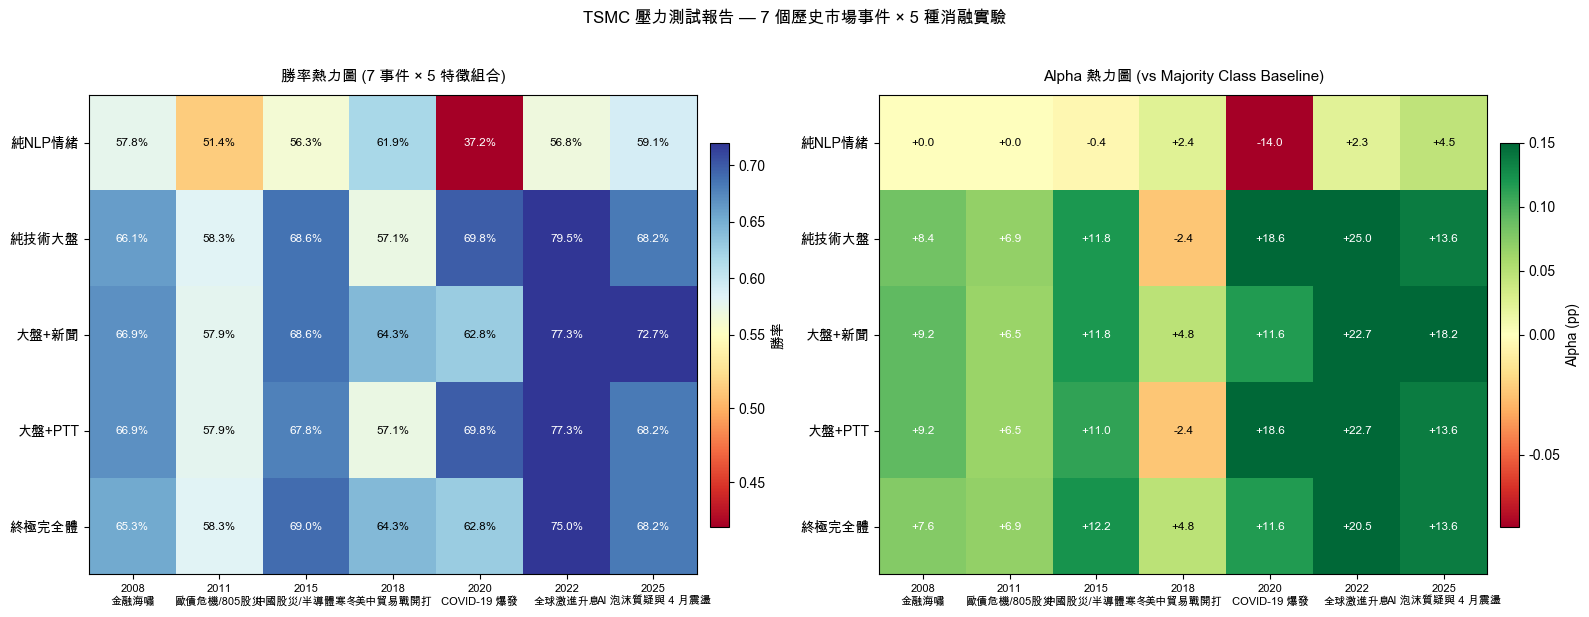

📊 消融圖 → stress_test_ablation.png


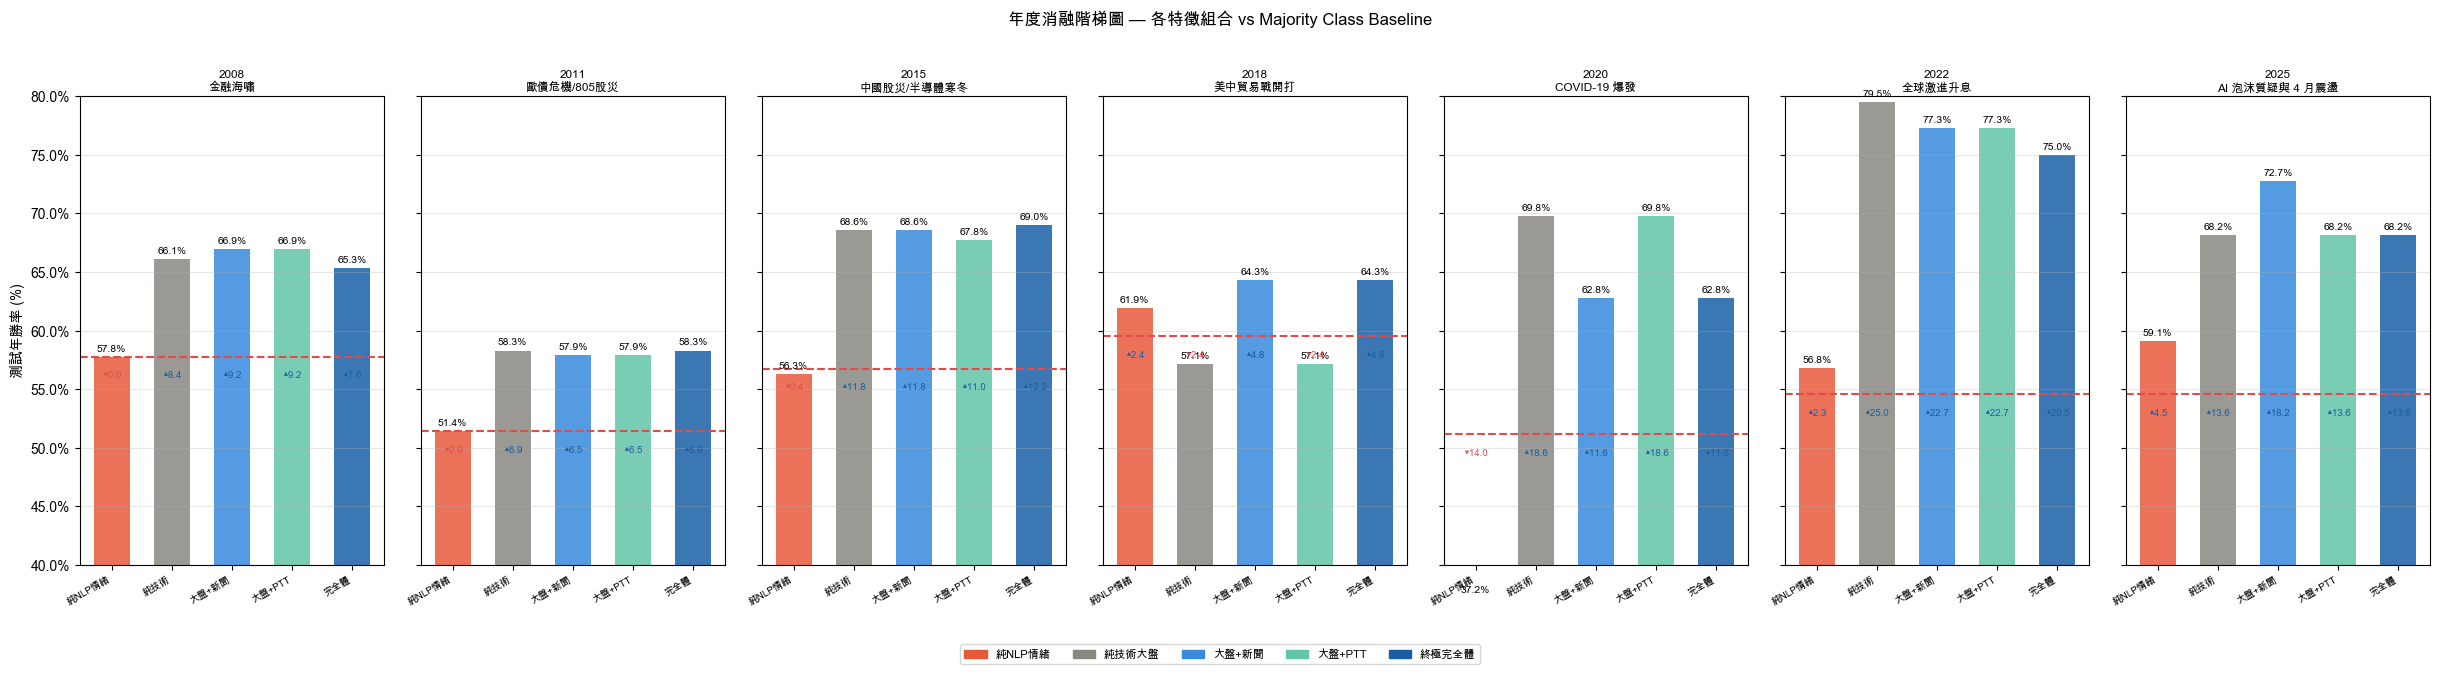


✅ 全部完成


In [10]:
"""
step4_stress_test.py
====================
7 個歷史事件 × 5 種消融實驗 = 35 個格子的成績表

完全對應規格:
  ✅ 演算法: VotingClassifier (RF + XGBoost, soft vote)
  ✅ StandardScaler 只 fit 在訓練集
  ✅ 滾動窗格切分 (Train 5年 → Test 1年)
  ✅ 每年對比 Majority Class Baseline
  ✅ 5 種消融特徵組合
  ✅ 7 大壓力測試年份
  ✅ NLP 正規化在每個訓練窗口內 OOS 執行
  ✅ 年度化動態錨向量 (訓練期漲跌日語料建立錨點)
  ✅ 輸出 Pandas DataFrame 對比表格
  ✅ matplotlib 年度消融階梯圖

輸入: TSMC_matrix_2000-2026.csv  (step3_merge_matrices.py 產出)
      cache_news_2000_2015.csv   (step1 產出, 供 NLP 錨向量重建)
      cache_news_2016_2026.csv   (step2 產出)
      cache_ptt_2000_2015.csv    (step1 產出)
      cache_ptt_2016_2026.csv    (step2 產出)

產出: stress_test_results.csv
      stress_test_heatmap.png    (熱力圖)
      stress_test_ablation.png   (年度消融階梯圖)
"""

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Arial Unicode MS"   # Windows: "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False

# ===========================================================================
# ⚙️  規格設定
# ===========================================================================

MATRIX_FILE = "TSMC_matrix_2000-2026.csv"   # ← 規格要求的最終檔名

# 7 大壓力測試 (規格要求)
STRESS_TEST_PERIODS = [
    # (測試年, 訓練起始年, 訓練結束年, 事件描述)
    (2008, 2003, 2007, "金融海嘯"),
    (2011, 2006, 2010, "歐債危機/805股災"),
    (2015, 2010, 2014, "中國股災/半導體寒冬"),
    (2018, 2013, 2017, "美中貿易戰開打"),
    (2020, 2015, 2019, "COVID-19 爆發"),
    (2022, 2017, 2021, "全球激進升息"),
    (2025, 2020, 2024, "AI 泡沫質疑與 4 月震盪"),
]

# 5 種消融實驗 (規格要求)
TECH_MACRO = [
    "VIX_Close", "ADR_Ret", "SOX_Ret", "FX_Ret",
    "RSI_14", "MACD", "MACD_Signal",
    "Ret_5D", "Ret_10D", "Ret_20D", "Ret_42D",
    "Vol_42D", "Position_42D",
]
NLP_NEWS = ["News_Score", "News_Volume"]
NLP_PTT  = ["PTT_Score",  "PTT_Volume"]

FEATURE_SETS = {
    "純NLP情緒":  NLP_NEWS + NLP_PTT,           # 僅 NLP
    "純技術大盤": TECH_MACRO,                    # 僅 Technical + Macro
    "大盤+新聞":  TECH_MACRO + NLP_NEWS,         # Base + News
    "大盤+PTT":   TECH_MACRO + NLP_PTT,          # Base + PTT
    "終極完全體": TECH_MACRO + NLP_NEWS + NLP_PTT,  # 全部
}

# NLP 靜態備用錨向量
STATIC_BULL = [
    "台積電股價大漲，法人大買超",
    "台積電業績超預期，訂單爆增",
    "半導體景氣回升，外資看好",
]
STATIC_BEAR = [
    "台積電股價重挫，法人大賣超",
    "台積電業績不如預期，訂單減少",
    "半導體景氣下滑，台積電受衝擊",
]

MIN_ANCHOR_DOCS = 30
MAX_ANCHOR_VECS = 3000


# ===========================================================================
# 📂  資料載入
# ===========================================================================
def load_matrix() -> pd.DataFrame:
    try:
        df = pd.read_csv(MATRIX_FILE, parse_dates=["Date"])
    except FileNotFoundError:
        raise FileNotFoundError(
            f"❌ 找不到 {MATRIX_FILE}\n"
            "   請依序執行:\n"
            "     python step1_build_2000_2015.py\n"
            "     python step2_build_2016_2026.py\n"
            "     python step3_merge_matrices.py"
        )
    df = df.set_index("Date").sort_index()
    df.index = pd.to_datetime(df.index).normalize()

    # 相容欄位名稱
    df.rename(columns={"PTT_Score":  "PTT_Raw_Score",
                        "News_Score": "News_Raw_Score"},
              inplace=True, errors="ignore")

    # 確保欄位存在
    for col in ["PTT_Raw_Score","News_Raw_Score","PTT_Volume","News_Volume"]:
        if col not in df.columns:
            df[col] = np.nan

    print(f"✅ 矩陣載入: {len(df)} 天 "
          f"({df.index.min().date()} ~ {df.index.max().date()})")
    return df


def load_title_caches() -> tuple[dict, dict]:
    """合併 2000-2015 和 2016-2026 的原始標題快取"""
    news_by_date, ptt_by_date = {}, {}

    for cache_file in ["cache_news_2000_2015.csv", "cache_news_2016_2026.csv"]:
        try:
            df_n = pd.read_csv(cache_file, parse_dates=["Date"])
            df_n["Date"] = pd.to_datetime(df_n["Date"]).dt.normalize()
            for _, row in df_n.iterrows():
                titles = json.loads(row["News_Titles"]) if isinstance(row["News_Titles"],str) else []
                news_by_date[row["Date"]] = titles
            print(f"   ✅ {cache_file}: {len(df_n)} 天")
        except FileNotFoundError:
            print(f"   ⚠️  找不到 {cache_file}")

    for cache_file in ["cache_ptt_2000_2015.csv", "cache_ptt_2016_2026.csv"]:
        try:
            df_p = pd.read_csv(cache_file, parse_dates=["Date"])
            df_p["Date"] = pd.to_datetime(df_p["Date"]).dt.normalize()
            for d, grp in df_p.groupby("Date"):
                ptt_by_date[d] = grp["Title"].tolist()
            print(f"   ✅ {cache_file}: {len(df_p)} 筆文章")
        except FileNotFoundError:
            print(f"   ⚠️  找不到 {cache_file}")

    return news_by_date, ptt_by_date


# ===========================================================================
# 🧠  Q1: 年度化動態錨向量 (訓練窗口內建立)
# ===========================================================================
def build_window_anchors(titles_by_date: dict,
                          df: pd.DataFrame,
                          train_start: int,
                          train_end: int,
                          nlp_model,
                          source: str,
                          max_per_class: int = 500) -> tuple:
    """
    從訓練窗口 (train_start ~ train_end) 中:
      · 上漲日的文章 → 看多錨向量
      · 下跌日的文章 → 看空錨向量
    使得每個事件（如金融海嘯、COVID）都有自己的市場語彙錨點。
    """
    train_mask = (df.index.year >= train_start) & (df.index.year <= train_end)
    train_df   = df[train_mask]

    bull_titles, bear_titles = [], []
    for date, row in train_df.iterrows():
        titles = titles_by_date.get(date, [])
        if not titles: continue
        if row.get("Target_Binary") == 1:
            bull_titles.extend(titles)
        else:
            bear_titles.extend(titles)

    np.random.seed(42)
    if len(bull_titles) > max_per_class:
        bull_titles = list(np.random.choice(bull_titles, max_per_class, replace=False))
    if len(bear_titles) > max_per_class:
        bear_titles = list(np.random.choice(bear_titles, max_per_class, replace=False))

    using_static = len(bull_titles) < MIN_ANCHOR_DOCS or len(bear_titles) < MIN_ANCHOR_DOCS
    if using_static:
        bull_titles = bull_titles or STATIC_BULL
        bear_titles = bear_titles or STATIC_BEAR

    bull_vec = nlp_model.encode(bull_titles, show_progress_bar=False).mean(axis=0)
    bear_vec = nlp_model.encode(bear_titles, show_progress_bar=False).mean(axis=0)

    note = ("靜態備用" if using_static
            else f"動態錨 bull={len(bull_titles)}篇 bear={len(bear_titles)}篇")
    print(f"         [{source}] {note}")

    return bull_vec, bear_vec


def compute_scores(titles_by_date: dict,
                   dates: pd.DatetimeIndex,
                   bull_vec: np.ndarray,
                   bear_vec: np.ndarray,
                   nlp_model) -> pd.Series:
    """對指定日期計算原始情緒分數（無文章 → NaN）"""
    scores = {}
    for date in dates:
        titles = titles_by_date.get(date, [])
        if not titles:
            scores[date] = np.nan
        else:
            vecs = nlp_model.encode(titles, show_progress_bar=False)
            bs   = cosine_similarity(vecs, bull_vec.reshape(1,-1)).flatten()
            es   = cosine_similarity(vecs, bear_vec.reshape(1,-1)).flatten()
            scores[date] = float((bs - es).mean())
    return pd.Series(scores)


# ===========================================================================
# 🔧  OOS NLP 正規化
#     只用訓練窗口 min/max，測試集嚴格不可見訓練集之後的分佈
# ===========================================================================
def normalize_oos(raw_series: pd.Series, train_idx: pd.Index) -> pd.Series:
    train_vals = raw_series.loc[raw_series.index.isin(train_idx)].dropna()
    if train_vals.empty or train_vals.max() == train_vals.min():
        return raw_series.fillna(0.5).clip(0, 1)
    s_min, s_max = train_vals.min(), train_vals.max()
    return ((raw_series - s_min) / (s_max - s_min)).clip(0, 1).fillna(0.5)


# ===========================================================================
# 🏗️  模型
# ===========================================================================
def build_model():
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=20,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1,
    )
    xgb = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42, verbosity=0,
    )
    return VotingClassifier(estimators=[("rf",rf),("xgb",xgb)],
                            voting="soft", n_jobs=-1)


# ===========================================================================
# 🎯  單一壓力測試
# ===========================================================================
def run_one_test(test_year, train_start, train_end, event_name,
                 df, news_by_date, ptt_by_date, nlp_model) -> dict:

    train_mask = (df.index.year >= train_start) & (df.index.year <= train_end)
    test_mask  = (df.index.year == test_year)

    if train_mask.sum() < 100 or test_mask.sum() < 20:
        print(f"   ⚠️  資料不足，跳過")
        return {"baseline": np.nan, "n_days": 0,
                **{k: np.nan for k in FEATURE_SETS}}

    train_idx = df.index[train_mask]
    test_idx  = df.index[test_mask]

    # ── 年度化動態錨向量 ────────────────────────────────────────────────────
    has_news = bool(news_by_date)
    has_ptt  = bool(ptt_by_date)

    if nlp_model is not None and (has_news or has_ptt):
        print(f"       🧠 建立 {train_start}~{train_end} 年度錨向量...")
        if has_news:
            news_bull, news_bear = build_window_anchors(
                news_by_date, df, train_start, train_end, nlp_model, "News")
        if has_ptt:
            ptt_bull,  ptt_bear  = build_window_anchors(
                ptt_by_date,  df, train_start, train_end, nlp_model, "PTT")

        # 計算整段 (train+test) 的原始情緒分數
        all_dates = train_idx.union(test_idx)

        news_raw = (compute_scores(news_by_date, all_dates, news_bull, news_bear, nlp_model)
                    if has_news else pd.Series(np.nan, index=all_dates))
        ptt_raw  = (compute_scores(ptt_by_date,  all_dates, ptt_bull,  ptt_bear,  nlp_model)
                    if has_ptt  else pd.Series(np.nan, index=all_dates))

        df_work = df.copy()
        df_work["News_Raw"] = news_raw
        df_work["PTT_Raw"]  = ptt_raw

        # OOS 正規化
        df_work["News_Score"] = normalize_oos(df_work["News_Raw"], train_idx)
        df_work["PTT_Score"]  = normalize_oos(df_work["PTT_Raw"],  train_idx)
    else:
        df_work = df.copy()
        # 若有預先計算的 Raw_Score，直接 OOS 正規化
        if "News_Raw_Score" in df_work.columns:
            df_work["News_Score"] = normalize_oos(df_work["News_Raw_Score"], train_idx)
        else:
            df_work["News_Score"] = 0.5
        if "PTT_Raw_Score" in df_work.columns:
            df_work["PTT_Score"] = normalize_oos(df_work["PTT_Raw_Score"], train_idx)
        else:
            df_work["PTT_Score"] = 0.5

    df_work["News_Volume"] = df_work.get("News_Volume", pd.Series(0, index=df_work.index)).fillna(0)
    df_work["PTT_Volume"]  = df_work.get("PTT_Volume",  pd.Series(0, index=df_work.index)).fillna(0)

    # ── 5 種消融實驗 ─────────────────────────────────────────────────────────
    y_full   = df_work["Target_Binary"]
    y_test   = y_full.loc[test_idx]
    baseline = float(y_test.value_counts(normalize=True).max())

    results = {"baseline": baseline, "n_days": len(test_idx)}

    for fs_name, fs_cols in FEATURE_SETS.items():
        avail = [c for c in fs_cols if c in df_work.columns]
        if not avail:
            results[fs_name] = np.nan
            continue

        X = df_work[avail].fillna(0.5)
        X_train, y_train = X.loc[train_idx], y_full.loc[train_idx]
        X_test_f         = X.loc[test_idx]

        scaler    = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test_f)

        mdl   = build_model()
        mdl.fit(X_train_s, y_train)
        preds = mdl.predict(X_test_s)
        acc   = accuracy_score(y_test, preds)
        results[fs_name] = acc

        beat = "▲" if acc > baseline else "▼"
        alpha = (acc - baseline) * 100
        print(f"         {beat} {fs_name:12s}: {acc:.1%}  "
              f"(Alpha {alpha:+.1f}pp vs 基準 {baseline:.1%})")

    return results


# ===========================================================================
# 📊  輸出規格要求的 DataFrame 表格
# ===========================================================================
def build_report_df(all_results: list) -> pd.DataFrame:
    fs_names = list(FEATURE_SETS.keys())
    rows = []
    for r in all_results:
        row = {
            "測試年份":    r["test_year"],
            "事件":        r["event_name"],
            "訓練期":      r["train_period"],
            "測試天數":    r["n_days"],
            "Baseline(%)": round(r["baseline"] * 100, 2) if not np.isnan(r["baseline"]) else np.nan,
        }
        for fs in fs_names:
            val = r.get(fs, np.nan)
            row[f"{fs}(%)"] = round(val * 100, 2) if not np.isnan(val) else np.nan
        # 完全體 Alpha
        full_acc = r.get("終極完全體", np.nan)
        base     = r.get("baseline", np.nan)
        row["完全體_Alpha(pp)"] = (
            round((full_acc - base) * 100, 2)
            if not (np.isnan(full_acc) or np.isnan(base)) else np.nan
        )
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


# ===========================================================================
# 🎨  視覺化 1: 熱力圖
# ===========================================================================
def plot_heatmap(all_results: list):
    fs_names = list(FEATURE_SETS.keys())
    event_labels = [f"{r['test_year']}\n{r['event_name']}" for r in all_results]
    mat      = np.array([[r.get(fs, np.nan) for fs in fs_names] for r in all_results])
    baselines = np.array([r.get("baseline", 0.5) for r in all_results]).reshape(-1, 1)
    excess   = mat - baselines

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── 左: 絕對勝率熱力圖
    ax1 = axes[0]
    norm = mcolors.TwoSlopeNorm(vmin=0.42, vcenter=0.55, vmax=0.72)
    im   = ax1.imshow(mat.T, aspect="auto", cmap=plt.cm.RdYlBu, norm=norm)
    ax1.set_xticks(range(len(event_labels)))
    ax1.set_xticklabels(event_labels, fontsize=8)
    ax1.set_yticks(range(len(fs_names)))
    ax1.set_yticklabels(fs_names, fontsize=10)
    ax1.set_title("勝率熱力圖 (7 事件 × 5 特徵組合)", fontsize=11, pad=10)
    for i in range(len(all_results)):
        for j in range(len(fs_names)):
            v = mat[i, j]
            if not np.isnan(v):
                color = "white" if (v < 0.48 or v > 0.65) else "black"
                ax1.text(i, j, f"{v:.1%}", ha="center", va="center",
                         fontsize=8.5, color=color, fontweight="bold")
    plt.colorbar(im, ax=ax1, fraction=0.03, pad=0.02, label="勝率")

    # ── 右: 超額勝率
    ax2 = axes[1]
    norm2 = mcolors.TwoSlopeNorm(vmin=-0.08, vcenter=0.0, vmax=0.15)
    im2   = ax2.imshow(excess.T, aspect="auto", cmap=plt.cm.RdYlGn, norm=norm2)
    ax2.set_xticks(range(len(event_labels)))
    ax2.set_xticklabels(event_labels, fontsize=8)
    ax2.set_yticks(range(len(fs_names)))
    ax2.set_yticklabels(fs_names, fontsize=10)
    ax2.set_title("Alpha 熱力圖 (vs Majority Class Baseline)", fontsize=11, pad=10)
    for i in range(len(all_results)):
        for j in range(len(fs_names)):
            v = excess[i, j]
            if not np.isnan(v):
                color = "white" if abs(v) > 0.06 else "black"
                ax2.text(i, j, f"{v*100:+.1f}", ha="center", va="center",
                         fontsize=8.5, color=color, fontweight="bold")
    plt.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02, label="Alpha (pp)")

    plt.suptitle("TSMC 壓力測試報告 — 7 個歷史市場事件 × 5 種消融實驗",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("stress_test_heatmap.png", dpi=150, bbox_inches="tight")
    print("📊 熱力圖 → stress_test_heatmap.png")
    plt.show()


# ===========================================================================
# 🎨  視覺化 2: 年度消融階梯圖 (規格要求)
# ===========================================================================
def plot_ablation_ladder(all_results: list):
    fs_names   = list(FEATURE_SETS.keys())
    colors     = {
        "純NLP情緒":  "#E8593C",
        "純技術大盤": "#888780",
        "大盤+新聞":  "#378ADD",
        "大盤+PTT":   "#63C5A8",
        "終極完全體": "#185FA5",
    }
    n_events   = len(all_results)
    fig, axes  = plt.subplots(1, n_events, figsize=(3.5 * n_events, 6), sharey=True)
    if n_events == 1:
        axes = [axes]

    for ax, r in zip(axes, all_results):
        base = r.get("baseline", np.nan)
        vals = [r.get(fs, np.nan) for fs in fs_names]

        # 基準線
        ax.axhline(base * 100, color="#E24B4A", ls="--", lw=1.5,
                   label=f"基準 {base:.1%}" if not np.isnan(base) else "")

        # 各特徵組條形
        x = np.arange(len(fs_names))
        for i, (fs, v) in enumerate(zip(fs_names, vals)):
            if np.isnan(v): continue
            color = colors.get(fs, "#aaa")
            alpha_val = (v - base) * 100 if not np.isnan(base) else 0
            ax.bar(i, v * 100, color=color, alpha=0.85, width=0.6, edgecolor="none")
            ax.text(i, v * 100 + 0.3, f"{v*100:.1f}%",
                    ha="center", va="bottom", fontsize=7.5, fontweight="bold")
            if not np.isnan(base):
                sign = "▲" if alpha_val > 0 else "▼"
                ax.text(i, base * 100 - 1.2,
                        f"{sign}{abs(alpha_val):.1f}", ha="center", va="top",
                        fontsize=7, color="#185FA5" if alpha_val > 0 else "#E24B4A")

        ax.set_xticks(x)
        ax.set_xticklabels([f.replace("終極完全體","完全體").replace("純技術大盤","純技術")
                             for f in fs_names], fontsize=7, rotation=30, ha="right")
        ax.set_title(f"{r['test_year']}\n{r['event_name']}", fontsize=8.5, pad=4)
        ax.set_ylim(40, 80)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("測試年勝率 (%)", fontsize=10)
    fig.suptitle("年度消融階梯圖 — 各特徵組合 vs Majority Class Baseline",
                 fontsize=12, fontweight="bold", y=1.02)

    # 共用 legend
    handles = [plt.Rectangle((0,0),1,1, color=colors[fs]) for fs in fs_names]
    fig.legend(handles, fs_names, loc="lower center", ncol=5,
               fontsize=8, bbox_to_anchor=(0.5, -0.08))

    plt.tight_layout()
    plt.savefig("stress_test_ablation.png", dpi=150, bbox_inches="tight")
    print("📊 消融圖 → stress_test_ablation.png")
    plt.show()


# ===========================================================================
# 🚀  主程序
# ===========================================================================
if __name__ == "__main__":
    print("=" * 65)
    print("🚀 Step 4 — 7 大壓力測試 × 5 種消融實驗")
    print("=" * 65)

    # ── 載入資料
    print("\n📂 [1] 載入矩陣...")
    df = load_matrix()

    print("\n📂 [2] 載入標題快取...")
    news_by_date, ptt_by_date = load_title_caches()

    # ── 載入 NLP 模型
    nlp_model = None
    if news_by_date or ptt_by_date:
        print("\n🧠 [3] 載入 SentenceTransformer...")
        try:
            from sentence_transformers import SentenceTransformer
            nlp_model = SentenceTransformer("shibing624/text2vec-base-chinese")
            print("   ✅ 模型就緒")
        except Exception as e:
            print(f"   ⚠️  {e} — 將使用靜態備用錨向量")

    # ── 執行 7 個壓力測試
    print("\n⚔️  [4] 執行壓力測試...")
    all_results = []

    for test_year, train_start, train_end, event_name in STRESS_TEST_PERIODS:
        print(f"\n  📅 {test_year} [{event_name}]  訓練: {train_start}~{train_end}")
        r = run_one_test(
            test_year, train_start, train_end, event_name,
            df, news_by_date, ptt_by_date, nlp_model,
        )
        r["test_year"]    = test_year
        r["event_name"]   = event_name
        r["train_period"] = f"{train_start}~{train_end}"
        all_results.append(r)

    # ── 輸出規格要求的 DataFrame
    print("\n" + "=" * 70)
    print("📋  規格要求輸出: Pandas DataFrame 對比表格")
    print("=" * 70)
    df_report = build_report_df(all_results)

    # 印出對齊表格
    display_cols = (["測試年份","事件","訓練期","測試天數","Baseline(%)"]
                    + [f"{k}(%)" for k in FEATURE_SETS]
                    + ["完全體_Alpha(pp)"])
    print(df_report[display_cols].to_string(index=False))

    # ── 各特徵組平均
    print("\n" + "-" * 70)
    print("📌  各特徵組 7 場壓力測試平均勝率 & 平均 Alpha:")
    base_col = "Baseline(%)"
    for fs in FEATURE_SETS:
        col  = f"{fs}(%)"
        avg  = df_report[col].mean()
        avg_b = df_report[base_col].mean()
        diff = avg - avg_b
        print(f"   {fs:14s}: 平均 {avg:.2f}%  (Alpha {diff:+.2f}pp vs 基準)")

    # ── 統計顯著性 (合併所有年份的勝率)
    print("\n" + "-" * 70)
    print("📐  統計顯著性 (跨所有壓力測試合併):")
    for fs in FEATURE_SETS:
        col = f"{fs}(%)"
        valid = df_report[[col, "Baseline(%)", "測試天數"]].dropna()
        if valid.empty: continue
        total_n    = int(valid["測試天數"].sum())
        total_wins = int((valid[col] / 100 * valid["測試天數"]).sum())
        avg_base   = valid["Baseline(%)"].mean() / 100
        b_test     = stats.binomtest(total_wins, total_n, avg_base, "greater")
        lo, hi     = proportion_confint(total_wins, total_n, 0.05, "wilson")
        sig = "✅" if b_test.pvalue < 0.05 else "  "
        print(f"   {sig} {fs:14s}: {total_wins}/{total_n}  "
              f"p={b_test.pvalue:.4f}  95%CI=[{lo:.1%},{hi:.1%}]")

    # ── 儲存
    df_report.to_csv("stress_test_results.csv", index=False)
    print(f"\n💾 結果 → stress_test_results.csv")

    # ── 視覺化
    print("\n🎨 [5] 繪製圖表...")
    plot_heatmap(all_results)
    plot_ablation_ladder(all_results)

    print("\n✅ 全部完成")